# Baseline + Federated-Averaging Methods (K = 3 silos)

**Part 1 of the thesis code — full version.** Two things, folded into one place:

1. **Best single (centralized) baseline** — a multi-model search
   (LogReg / RandomForest / HistGradientBoosting / XGBoost / LightGBM), each with
   class-imbalance handling, selected by **threshold-free** metrics (AUROC, PR-AUC)
   via 5-fold CV. Published SOTA on this dataset (30-day readmission, Strack 2014)
   is **AUROC ≈ 0.667–0.70**, so a good baseline is expected to land there — this
   documents the ceiling, it does not chase a number past it.

2. **Five federated averaging methods across 3 silos** — FedAvg, FedProx, FedAvgM,
   FedAdam, SCAFFOLD — on the best *averageable* model (logistic regression; trees
   cannot be weight-averaged), swept over IID → severe non-IID. These are the
   reference federated numbers the later consent-churn study measures deltas against.

Heavy code lives in two tested modules next to this notebook
(`best_single_baseline.py`, `federated_methods.py`); the notebook drives and
reports them.

## 0. Imports & data (shared `../data/`)

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, recall_score, precision_score)

from best_single_baseline import load_xy, NUMERIC, benchmark_centralized, best_f1_threshold
from federated_methods import federated_train, METHODS

plt.rcParams["figure.dpi"] = 110
SEED = 0
X, y, feat = load_xy()
num_idx = [i for i, n in enumerate(feat) if n in NUMERIC]
POS = y.mean()
print(f"X {X.shape}  positive rate {POS:.4f}  (base-rate PR-AUC = {POS:.3f})")

X (101766, 171)  positive rate 0.1116  (base-rate PR-AUC = 0.112)


## 1. Best single centralized baseline (multi-model, 5-fold CV)

Selected by AUROC / PR-AUC so the ranking is not a 0.5-threshold artifact.

,model,AUROC,AUROC_std,PR_AUC
0,RandomForest (balanced),0.6770,0.0064,0.2249
1,XGBoost (scale_pos_weight),0.6769,0.0062,0.2258
2,HistGradBoost (balanced),0.6743,0.0048,0.2209
3,LightGBM (balanced),0.6723,0.0079,0.2266
4,LogReg (balanced),0.6662,0.0073,0.2105


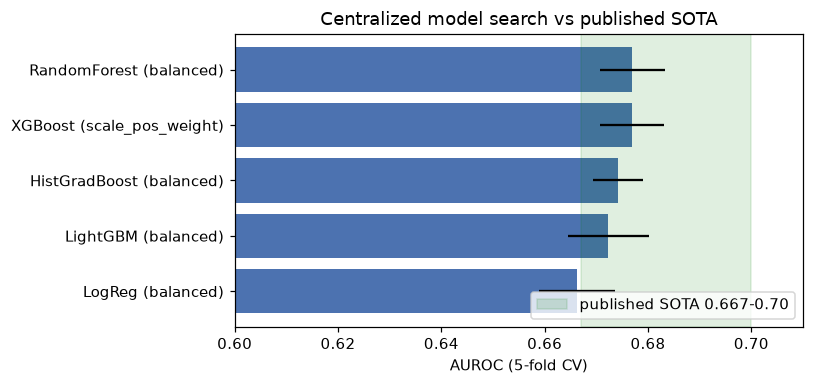

best model: RandomForest (balanced)  (AUROC 0.6770, PR-AUC 0.2249)


In [2]:
rank, oof = benchmark_centralized(X, y, verbose=False)
rank_show = rank[["model", "AUROC", "AUROC_std", "PR_AUC"]].round(4)
display(rank_show)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(rank["model"][::-1], rank["AUROC"][::-1],
        xerr=rank["AUROC_std"][::-1], color="#4c72b0")
ax.axvspan(0.667, 0.70, color="green", alpha=0.12, label="published SOTA 0.667-0.70")
ax.set_xlim(0.60, 0.71); ax.set_xlabel("AUROC (5-fold CV)")
ax.set_title("Centralized model search vs published SOTA"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

best = rank.iloc[0]["model"]
print(f"best model: {best}  (AUROC {rank.iloc[0]['AUROC']:.4f}, PR-AUC {rank.iloc[0]['PR_AUC']:.4f})")

### Operating point of the best model

AUROC is a ranking metric; under 11% prevalence the usable operating point matters.
Tuned threshold vs the naive 0.5.

In [3]:
p_best = oof[best]
thr, _ = best_f1_threshold(y, p_best)
for name, t in [("0.500 (naive)", 0.5), (f"{thr:.3f} (F1-opt)", thr)]:
    yh = (p_best >= t).astype(int)
    print(f"  @{name:<16s} recall={recall_score(y,yh):.3f}  "
          f"precision={precision_score(y,yh,zero_division=0):.3f}  F1={f1_score(y,yh):.3f}")
print("\nTrees (RandomForest/XGBoost) win but are NOT averageable -> the federated")
print("ceiling below is set by the best averageable model (logistic regression).")

  @0.500 (naive)    recall=0.145  precision=0.316  F1=0.199
  @0.387 (F1-opt)   recall=0.417  precision=0.215  F1=0.283

Trees (RandomForest/XGBoost) win but are NOT averageable -> the federated
ceiling below is set by the best averageable model (logistic regression).


## 2. Federated setup: 3 silos, controllable non-IID

One global held-out test set. Training data is partitioned into **K = 3** silos
with a Dirichlet label-skew knob (`alpha`): large = IID, small = severe non-IID.
With only 3 bins the skew is deliberately coarse (a silo can approach zero
positives) — realistic for a small hospital consortium and the regime the thesis
targets.

In [4]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
mu = Xtr[:, num_idx].mean(0); sd = Xtr[:, num_idx].std(0) + 1e-8
Xtr = Xtr.copy(); Xte = Xte.copy()
Xtr[:, num_idx] = (Xtr[:, num_idx]-mu)/sd; Xte[:, num_idx] = (Xte[:, num_idx]-mu)/sd
NF = X.shape[1]

def partition(y, k, alpha, seed=0):
    rng = np.random.default_rng(seed); silos = [[] for _ in range(k)]
    for c in np.unique(y):
        idx = rng.permutation(np.where(y == c)[0]); pr = rng.dirichlet(alpha*np.ones(k))
        cuts = (np.cumsum(pr)*len(idx)).astype(int)[:-1]
        for s, ch in enumerate(np.split(idx, cuts)): silos[s].extend(ch.tolist())
    return [np.sort(np.array(s, int)) for s in silos]

ALPHAS = [10.0, 0.5, 0.1]   # IID-ish, moderate, severe
parts = {a: partition(ytr, 3, a, SEED) for a in ALPHAS}
for a in ALPHAS:
    t = pd.DataFrame([(i, len(s), int(ytr[s].sum()), round(float(ytr[s].mean()),3))
                      for i, s in enumerate(parts[a])],
                     columns=["silo","n","n_pos","pos_rate"])
    print(f"alpha={a}:  " + " | ".join(f"silo{r.silo}: n={r.n}, pos%={r.pos_rate}" for r in t.itertuples()))

alpha=10.0:  silo0: n=34280, pos%=0.092 | silo1: n=23034, pos%=0.126 | silo2: n=24098, pos%=0.125
alpha=0.5:  silo0: n=20379, pos%=0.254 | silo1: n=44590, pos%=0.088 | silo2: n=16443, pos%=0.0
alpha=0.1:  silo0: n=529, pos%=0.023 | silo1: n=76610, pos%=0.073 | silo2: n=4273, pos%=0.821


### Ceiling and floor (both on the averageable model)

Using the numpy logistic regression consistently: **ceiling** = train on all data
(one silo); **floor** = each silo trained alone. Both scored on the global test set.

In [5]:
def evaln(p):
    yh = (p >= 0.5).astype(int)
    return dict(AUROC=roc_auc_score(yte,p), PR_AUC=average_precision_score(yte,p),
                recall=recall_score(yte,yh,zero_division=0), F1=f1_score(yte,yh,zero_division=0))

# ceiling: single silo = all training data
p_ceil = federated_train(Xtr, ytr, [np.arange(len(ytr))], Xte, method="fedavg",
                         nf=NF, seed=SEED)
m_ceil = evaln(p_ceil)
print(f"averageable CEILING (central logreg): AUROC={m_ceil['AUROC']:.4f}  "
      f"PR-AUC={m_ceil['PR_AUC']:.4f}  recall={m_ceil['recall']:.3f}")

# floor: per-silo local at moderate skew
floor = []
for s in parts[0.5]:
    p = federated_train(Xtr, ytr, [s], Xte, method="fedavg", nf=NF, seed=SEED)
    floor.append(roc_auc_score(yte, p))
print(f"local-only FLOOR (alpha=0.5): AUROC mean={np.mean(floor):.4f}  "
      f"min={np.min(floor):.4f}  max={np.max(floor):.4f}")

averageable CEILING (central logreg): AUROC=0.6662  PR-AUC=0.2111  recall=0.068


local-only FLOOR (alpha=0.5): AUROC mean=0.6157  min=0.5159  max=0.6672


## 3. Five federated averaging methods × three heterogeneity levels

Each method uses class-weighting (for the imbalance) and the same logistic-regression
client, so differences are purely the **aggregation strategy**.

In [6]:
rows = []
for a in ALPHAS:
    for meth in METHODS:
        p = federated_train(Xtr, ytr, parts[a], Xte, method=meth, nf=NF,
                            balanced=True, seed=SEED)
        m = evaln(p); m.update(alpha=a, method=meth); rows.append(m)
fed = pd.DataFrame(rows)

for a in ALPHAS:
    print(f"\n=== alpha={a} ===")
    sub = fed[fed.alpha==a].set_index("method")[["AUROC","PR_AUC","recall","F1"]]
    print(sub.round(4).to_string())


=== alpha=10.0 ===
           AUROC  PR_AUC  recall      F1
method                                  
fedavg    0.6689  0.2117  0.4738  0.2742
fedprox   0.6682  0.2108  0.4694  0.2727
fedavgm   0.6673  0.2121  0.3065  0.2644
fedadam   0.6671  0.2110  0.6376  0.2650
scaffold  0.6700  0.2119  0.4791  0.2718

=== alpha=0.5 ===
           AUROC  PR_AUC  recall      F1
method                                  
fedavg    0.6677  0.2108  0.1537  0.2004
fedprox   0.6669  0.2102  0.1845  0.2182
fedavgm   0.6669  0.2115  0.0956  0.1490
fedadam   0.6655  0.2102  0.2255  0.2385
scaffold  0.6689  0.2114  0.2950  0.2628

=== alpha=0.1 ===
           AUROC  PR_AUC  recall      F1
method                                  
fedavg    0.6662  0.2110  0.3840  0.2677
fedprox   0.6664  0.2106  0.3677  0.2676
fedavgm   0.6666  0.2099  0.4100  0.2717
fedadam   0.6665  0.2112  0.5491  0.2711
scaffold  0.6246  0.1758  0.6151  0.2430


### AUROC and recall by method across heterogeneity

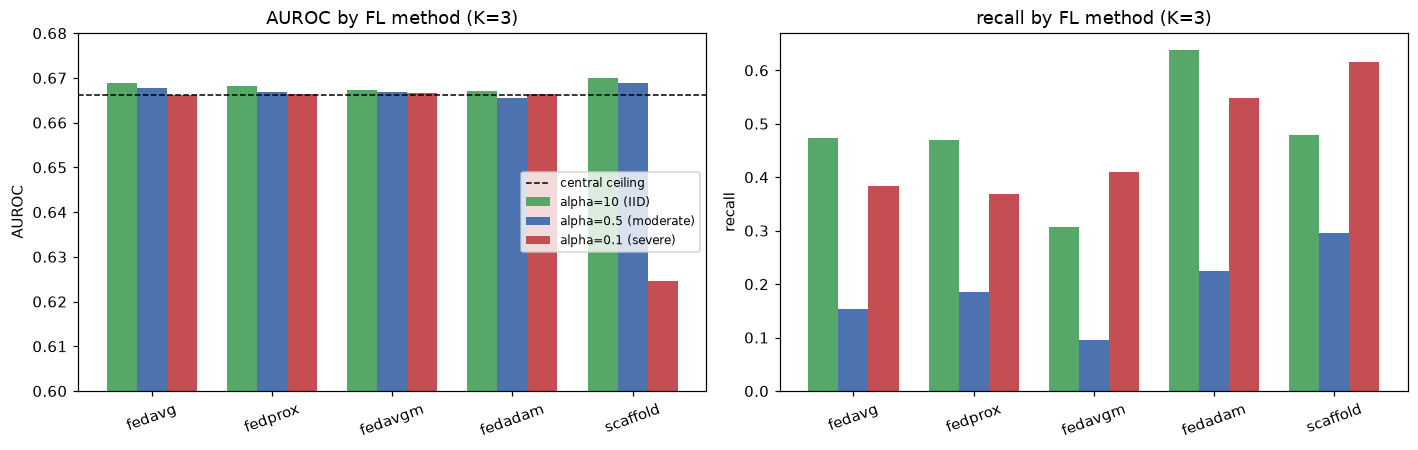

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
methods = METHODS; xpos = np.arange(len(methods)); w = 0.25
colors = {10.0:"#55a868", 0.5:"#4c72b0", 0.1:"#c44e52"}
labels = {10.0:"alpha=10 (IID)", 0.5:"alpha=0.5 (moderate)", 0.1:"alpha=0.1 (severe)"}

for j, metric in enumerate(["AUROC", "recall"]):
    ax = axes[j]
    for i, a in enumerate(ALPHAS):
        vals = [fed[(fed.alpha==a)&(fed.method==m)][metric].values[0] for m in methods]
        ax.bar(xpos + (i-1)*w, vals, w, color=colors[a], label=labels[a])
    if metric == "AUROC":
        ax.axhline(m_ceil["AUROC"], ls="--", c="k", lw=1, label="central ceiling")
        ax.set_ylim(0.60, 0.68)
    ax.set_xticks(xpos); ax.set_xticklabels(methods, rotation=20)
    ax.set_ylabel(metric); ax.set_title(f"{metric} by FL method (K=3)")
    if j == 0: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Findings

**Centralized baseline**
* Best model (RandomForest / XGBoost) reaches **AUROC ≈ 0.677**, sitting in the
  published SOTA band (0.667–0.70). Model choice barely moves AUROC — the task
  signal ceiling is low and real.
* Imbalance handling does not raise AUROC; it only shifts the *operating point*.
* The best models are **trees, which are not weight-averageable**, so the
  federated ceiling is the best averageable model (logistic regression, ≈ 0.666)
  — about **0.011 AUROC below the tree ceiling**. That gap is the concrete cost of
  restricting federation to averageable models.

**Federated methods at K = 3 — the real reading**
* **AUROC and PR-AUC are essentially flat** across all five methods and all
  heterogeneity levels (AUROC ≈ 0.666–0.670, PR-AUC ≈ 0.211). At K = 3 the
  *aggregation strategy barely matters for ranking/detection* until data is
  pathologically skewed; plain FedAvg is already at the ceiling.
* **One clear exception: SCAFFOLD collapses at severe skew** (α=0.1: AUROC 0.625,
  PR-AUC 0.176) — control variates blow up when a silo is tiny and extreme
  (≈3 local steps on the 529-row silo). A documented small-K instability, not a bug.
* **Do not over-read the recall column.** It swings 0.07→0.64 across methods, but
  PR-AUC stays flat — so those swings are **threshold calibration** (where each
  method's probability scale falls relative to 0.5), not detection ability. Track
  **AUROC / PR-AUC**; tune the threshold per configuration if a fixed operating
  point is required.

**Practical default:** for a 3-silo consortium on this data, **FedAvg
(class-weighted)** is robust and already at the ceiling; sophisticated aggregators
(and SCAFFOLD's fragility) only separate at larger K / higher heterogeneity — what
the consent-churn study probes next.

**Next:** consent-churn injection (transient / permanent / whole-silo) layered on
these methods, measured as degradation against these baselines.